In [32]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


In [33]:
SELECTED_EVENTS = 1
EVENT_COUNT = 12
BATCH_SIZE = 4
PATCH_SIZE = 4

In [34]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    ssim_values: list[float], 
    epochs: int, 
    y_title: str, 
    title: str
) -> None:
    print("ssmi values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ssim_values)
    plt.xlabel('Epochs')
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
def collate_fn(batch: torch.tensor):
    tensors = [
        torch.tensor(x).reshape(
            PATCH_SIZE, 
            PATCH_SIZE
        ).unsqueeze(1).unsqueeze(1).permute(1, 2, 0, 3)
        for x in batch
    ]
    return tensors

def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

In [35]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 272.89it/s]


In [36]:
# Params
batch_size = 64
learning_rate = 1e-2
# num_epochs = 80
num_epochs = 60
channels = 1
latent_dim = 12
num_embeddings = 64  # Number of vectors in the codebook
beta = 0.5 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2


decay = 0.75
vq_epsilon = 1e-5

# TODO: 4 x 4 compress to 2 x 2

In [37]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [38]:
event_train = events_train[:SELECTED_EVENTS][0]


In [39]:
events_train_display = iter(events_train)

In [40]:
event_train_patches = event_hits_to_patches(event_train, patch_size=PATCH_SIZE)
event_train_patches_adcs = event_train_patches.as_array()
event_train_patches_adcs.shape

(20742, 16)

In [41]:
event_train_patches_adcs[0].shape

(16,)

In [42]:
len(event_train_patches_adcs)

20742

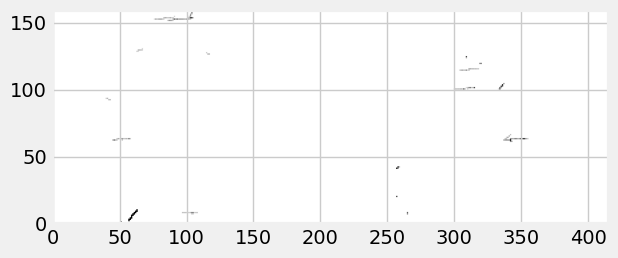

In [43]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [44]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_loader = DataLoader(
    dataset=event_train_patches_adcs, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=collate_fn
)

In [45]:
data_sample = next(iter(train_loader))
data_sample[0].shape

torch.Size([1, 1, 4, 4])

In [46]:
len(train_loader)

325

In [47]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        # inputs = inputs.permute(1, 0, 2, 3).contiguous()
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        # quantized = quantized.permute(0, 3, 2, 1).contiguous()  # [B, C, H, W]
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encodings
        )

In [48]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [ ]:

class VQVAE(nn.Module):
    def __init__(self, debug: bool=False):
        super(VQVAE, self).__init__()
        # k
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 3, kernel_size=2, stride=1),
            nn.ReLU(),
            nn.Conv2d(3, latent_dim, kernel_size=2),
            nn.ReLU(),
            # nn.Conv2d(6, latent_dim, kernel_size=1),
            # nn.ReLU()
            # nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            # nn.Conv2d(32, 64, kernel_size=2, stride=1, padding=1),
          
            # nn.LeakyReLU(0.1),
            # nn.Conv2d(64, latent_dim, kernel_size=2),
            # ResidualStack(
            #     in_channels=latent_dim,channels
            #     num_hiddens=latent_dim,
            #     num_residual_layers=num_residual_layers,
            #     num_residual_hiddens=num_residual_hiddens,
            # )
        )
        self.debug = debug

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            # ResidualStack(
            #     in_channels=latent_dim,
            #     num_hiddens=latent_dim,
            #     num_residual_layers=num_residual_layers,
            #     num_residual_hiddens=num_residual_hiddens,
            # ),
            nn.ConvTranspose2d(latent_dim, 3, kernel_size=2),
            nn.ReLU(),
            nn.ConvTranspose2d(3, channels, kernel_size=2, stride=1),
            nn.ReLU(),
            # nn.ConvTranspose2d(3, channels, kernel_size=2, stride=1),
            # nn.ReLU(),
            # nn.ConvTranspose2d(6, channels, kernel_size=2, stride=1),
            # nn.ReLU(),
            # nn.ConvTranspose2d(64, 32, kernel_size=2, stride=1, padding=1),
            # nn.LeakyReLU(0.1),
            # nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1),
            # nn.LeakyReLU(0.1),
            # nn.ConvTranspose2d(16, channels, kernel_size=2, stride=1, padding=1),
            # nn.Sigmoid() 
        )
        self.debug = debug

    def forward(self, x):
        z_e = self.encoder(x)        
        
        # print(f"Compressed shape: {z_e.shape}")
        
        z_q, vq_loss, perplexity, encodings = self.vq_layer(z_e)
        used_codes = torch.sum(encodings, dim=0) > 0
        num_used = used_codes.sum()
        
        if self.debug:
            print(f"Compressed shape: {z_q.shape}")
            print(f"Codebooks: {num_used}")
        
        
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss, perplexity

In [50]:
model = VQVAE().to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

In [51]:
# # debug
# model.train()
# event_patch = next(iter(train_loader))
# event_patch_train = event_patch[0].float().to(device)
# model.encoder(event_patch_train).shape



Epoch 1/60: 100%|██████████| 325/325 [00:00<00:00, 788.15it/s, Loss=13.7]   


Before compression
Before: (4, 4)


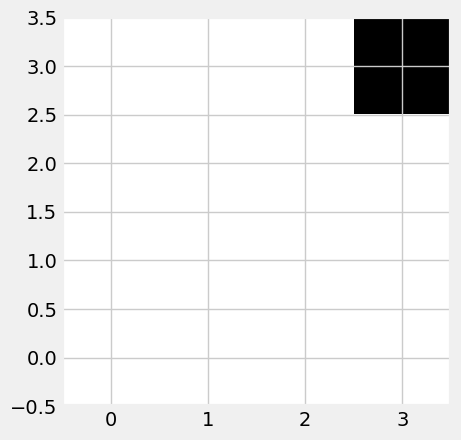

After: (4, 4)
After compression


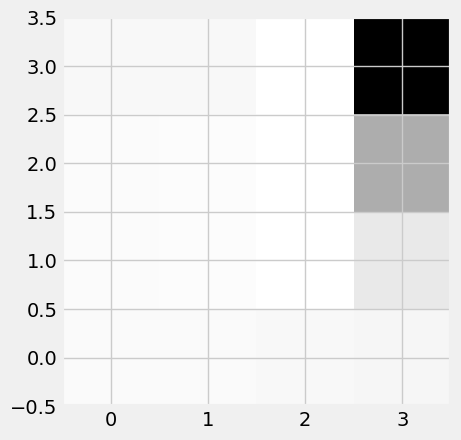

Training SSIM value: 0.3695121919736266
Perplexity: 2.8284270763397217
Epoch [1/60] Average Loss: 748.0988


Epoch 2/60: 100%|██████████| 325/325 [00:00<00:00, 799.01it/s, Loss=29.7]   


Epoch [2/60] Average Loss: 462.8813


Epoch 3/60: 100%|██████████| 325/325 [00:00<00:00, 797.26it/s, Loss=742]    


Epoch [3/60] Average Loss: 317.3730


...

Epoch [9/60] Average Loss: 235.5008


Epoch 10/60: 100%|██████████| 325/325 [00:00<00:00, 769.75it/s, Loss=187]    


Epoch [10/60] Average Loss: 202.7528


Epoch 11/60: 100%|██████████| 325/325 [00:00<00:00, 737.31it/s, Loss=77.8]   


Before compression
Before: (4, 4)


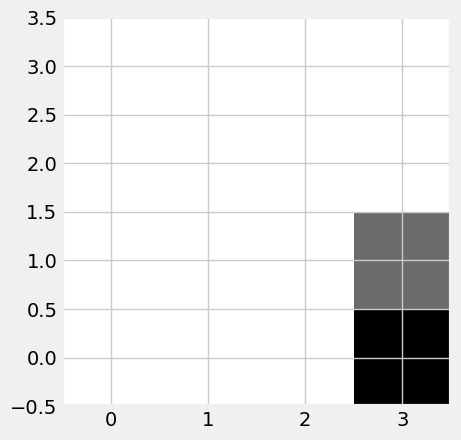

After: (4, 4)
After compression


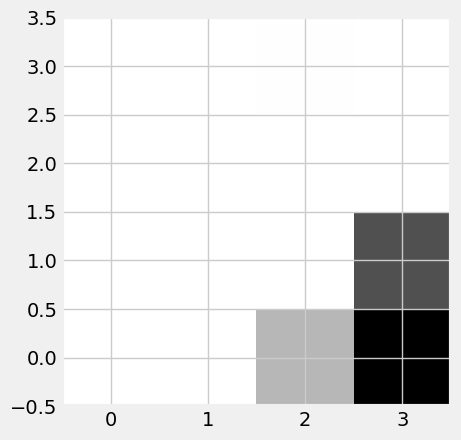

Training SSIM value: 0.7328365261200815
Perplexity: 4.0
Epoch [11/60] Average Loss: 314.6660


Epoch 12/60: 100%|██████████| 325/325 [00:00<00:00, 792.15it/s, Loss=2.85]   


Epoch [12/60] Average Loss: 244.6911


Epoch 13/60: 100%|██████████| 325/325 [00:00<00:00, 809.57it/s, Loss=86.2]   


Epoch [13/60] Average Loss: 269.9635


...

Epoch [19/60] Average Loss: 202.7569


Epoch 20/60: 100%|██████████| 325/325 [00:00<00:00, 786.02it/s, Loss=0.561]  


Epoch [20/60] Average Loss: 171.7846


Epoch 21/60: 100%|██████████| 325/325 [00:00<00:00, 808.24it/s, Loss=19.9]   


Before compression
Before: (4, 4)


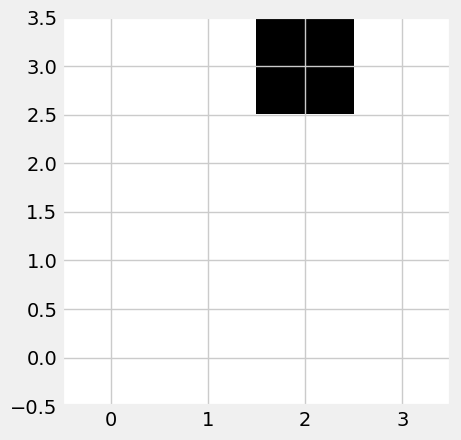

After: (4, 4)
After compression


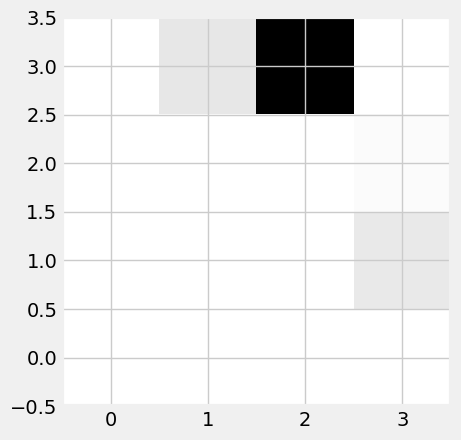

Training SSIM value: 0.787309505045414
Perplexity: 1.7547653913497925
Epoch [21/60] Average Loss: 349.3280


Epoch 22/60: 100%|██████████| 325/325 [00:00<00:00, 809.44it/s, Loss=36.1]   


Epoch [22/60] Average Loss: 210.3055


Epoch 23/60: 100%|██████████| 325/325 [00:00<00:00, 797.88it/s, Loss=78.8]   


Epoch [23/60] Average Loss: 191.0351


...

Epoch [29/60] Average Loss: 171.2419


Epoch 30/60: 100%|██████████| 325/325 [00:00<00:00, 769.46it/s, Loss=27.6]   


Epoch [30/60] Average Loss: 157.8405


Epoch 31/60: 100%|██████████| 325/325 [00:00<00:00, 794.00it/s, Loss=0.676]  


Before compression
Before: (4, 4)


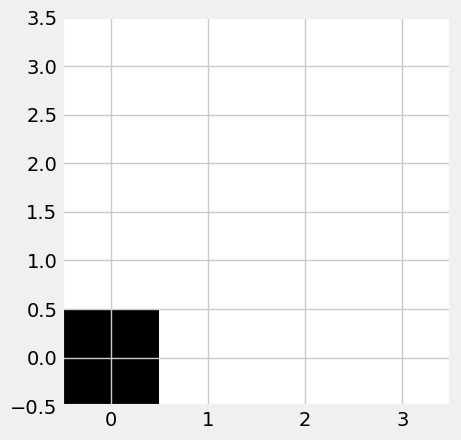

After: (4, 4)
After compression


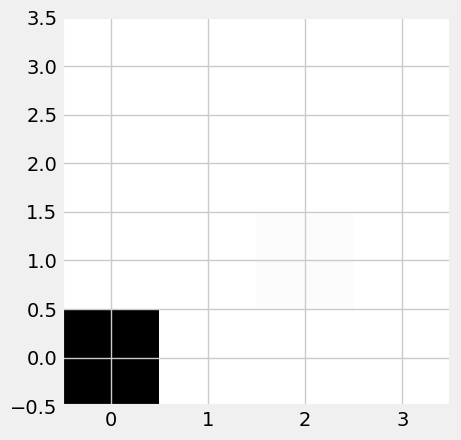

Training SSIM value: 0.962054893374443
Perplexity: 2.8284270763397217
Epoch [31/60] Average Loss: 203.0201


Epoch 32/60: 100%|██████████| 325/325 [00:00<00:00, 775.95it/s, Loss=10.4]   


Epoch [32/60] Average Loss: 154.7447


Epoch 33/60: 100%|██████████| 325/325 [00:00<00:00, 787.40it/s, Loss=21.9]   


Epoch [33/60] Average Loss: 145.8274


...

Epoch [39/60] Average Loss: 157.4591


Epoch 40/60: 100%|██████████| 325/325 [00:00<00:00, 787.06it/s, Loss=23.6]   


Epoch [40/60] Average Loss: 96.3439


Epoch 41/60: 100%|██████████| 325/325 [00:00<00:00, 802.65it/s, Loss=58.5]   


Before compression
Before: (4, 4)


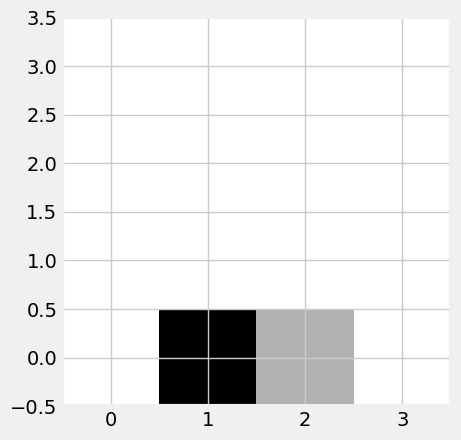

After: (4, 4)
After compression


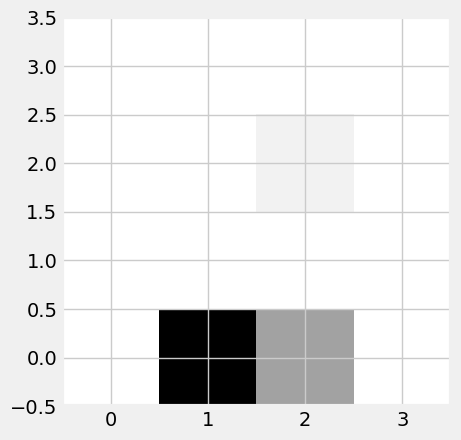

Training SSIM value: 0.7709684669971466
Perplexity: 2.8284270763397217
Epoch [41/60] Average Loss: 155.7753


Epoch 42/60: 100%|██████████| 325/325 [00:00<00:00, 795.20it/s, Loss=0.528] 


Epoch [42/60] Average Loss: 127.0804


Epoch 43/60: 100%|██████████| 325/325 [00:00<00:00, 796.43it/s, Loss=227]    


Epoch [43/60] Average Loss: 132.8539


...

Epoch [49/60] Average Loss: 268.9021


Epoch 50/60: 100%|██████████| 325/325 [00:00<00:00, 781.33it/s, Loss=99.6]   


Epoch [50/60] Average Loss: 145.1612


Epoch 51/60: 100%|██████████| 325/325 [00:00<00:00, 791.39it/s, Loss=138]    


Before compression
Before: (4, 4)


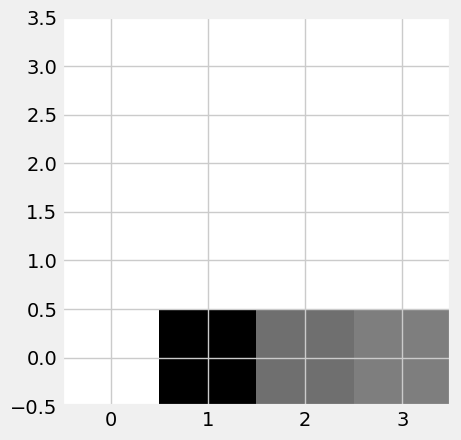

After: (4, 4)
After compression


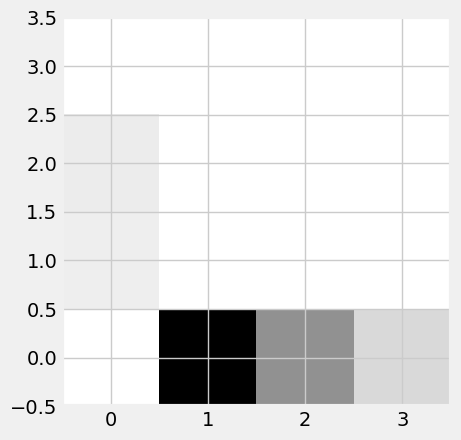

Training SSIM value: 0.742337629199028
Perplexity: 2.8284270763397217
Epoch [51/60] Average Loss: 162.6973


Epoch 52/60: 100%|██████████| 325/325 [00:00<00:00, 836.97it/s, Loss=105]   


Epoch [52/60] Average Loss: 90.9580


Epoch 53/60: 100%|██████████| 325/325 [00:00<00:00, 822.33it/s, Loss=0.754]  


Epoch [53/60] Average Loss: 133.6643


...

Epoch [58/60] Average Loss: 220.6232


Epoch 59/60: 100%|██████████| 325/325 [00:00<00:00, 805.24it/s, Loss=72.4]   


Epoch [59/60] Average Loss: 183.8657


Epoch 60/60: 100%|██████████| 325/325 [00:00<00:00, 790.21it/s, Loss=21.7]   


Epoch [60/60] Average Loss: 115.6862


In [52]:
# loss
average_loss_values = []

# ssim
ssim_values = []

# perplexity
perplexity_values = []

epoch_values = list(range(num_epochs))

for epoch in epoch_values:
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    for batch_idx, patch_adcs in progress_bar:
        X_adcs = patch_adcs[0]
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)

        optimizer.zero_grad()
        
        # Required for treating as images

        # target = patches_adcs.view(B * N, C, 1, W)

        recon_patch, vq_loss, perplexity = model(
            X_adcs
        )
        recon_patch = recon_patch.float()
    
        loss = _get_vq_loss(recon_patch, X_adcs, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
    
    if epoch % 10 == 0:
        with torch.no_grad():            
            # selecting events before reconstruction
            print("Before compression")
            patch_original = _tensor_to_numpy(
                X_adcs.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            
            print(f"Before: {patch_original.shape}")
            
            plot_patch(patch_original)
            
            recon_patch, _, perplexity = model(X_adcs)
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            plot_patch(recon_patch_np)
            
            
            perplexity_values.append(perplexity.cpu().numpy())
            
            
            
            ssim_value = _get_ssim_value(
                patch_original,
                recon_patch_np
            )
            print(f"Training SSIM value: {ssim_value}")
            
            ssim_values.append(ssim_value)
            
            print(f"Perplexity: {perplexity}")
            
        
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

In [ ]:
event_test = events_test[0]
event_patches_adcs = iter(event_hits_to_patches(event_test, PATCH_SIZE).as_array())

X_test = next(
    event_patches_adcs
)
X_test = torch.tensor(X_test).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).unsqueeze(1).permute(1, 2, 0, 3)

model.eval()

with torch.no_grad():
    model = VQVAE(debug=True).to(device)
    z = model.encoder(X_test)
    z, vq_loss, perplexity, encodings = model.vq_layer(z)
    print(f"Latent shape: {z.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    print(f"Codebook:{len(used_codes)}")
    print(encodings.shape)
    print(encodings.unique())
    

Latent shape: torch.Size([1, 12, 2, 2])
Codebook:2
torch.Size([4, 64])
tensor([0., 1.], device='cuda:0')


In [54]:
events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_1965806/3809575644.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


ssmi values over epochs


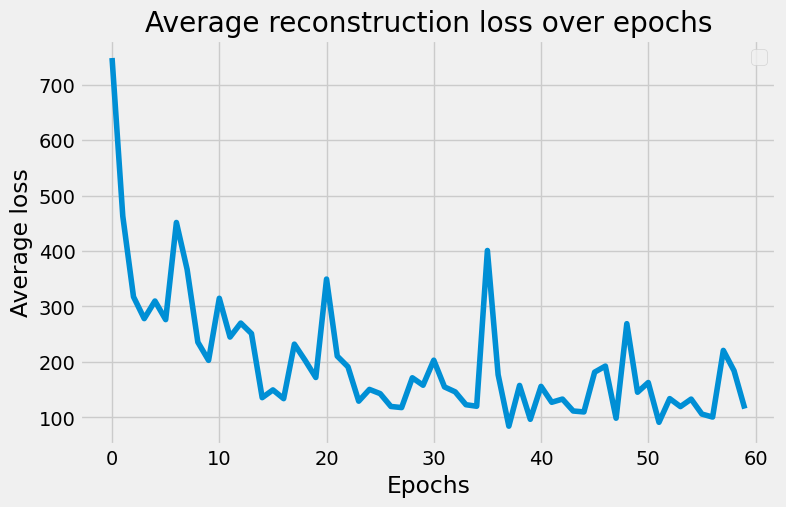

In [55]:
plot_metric_results(
    average_loss_values, 
    epoch_values, 
    "Average loss", 
    "Average reconstruction loss over epochs"
)

In [56]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [57]:
# Test model with unseen data
event_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]
event_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(event_test_patches_adcs)}")
print(f"Event patches: {len(event_test_patches[0])}")


Events test: 1
Event patches: 10871


In [58]:
# TODO: change debug for option change event_hit_test count
EVENT_PATCH_GROUP_ID = 0
patches_test_adcs_tensors = [
    torch.tensor(
        event_patch.reshape(PATCH_SIZE, PATCH_SIZE)
    ).unsqueeze(1).unsqueeze(1).transpose(0, 2)
    for event_patch in event_test_patches_adcs[EVENT_PATCH_GROUP_ID]
]
patches_test_adcs_tensors[0].shape

torch.Size([1, 1, 4, 4])

Testing with unseen data
Before: (4, 4)


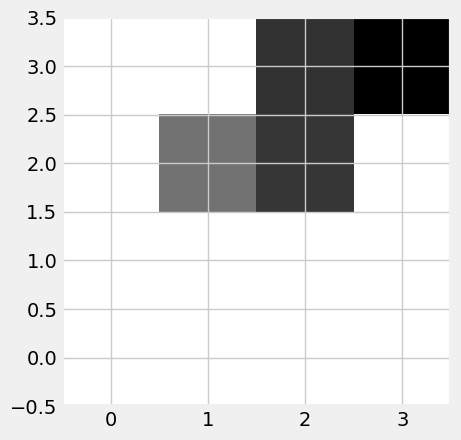

After: (4, 4)
After compression


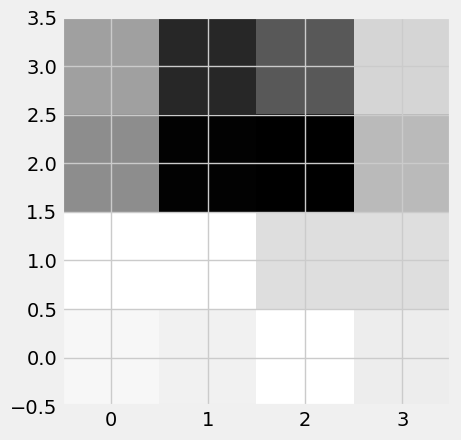

In [67]:
# testing with new data
patches_test_adcs_tensor = iter(patches_test_adcs_tensors)
event_test_patches = iter(event_test_patches)
model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
model.eval()    

event_patches_decompressed = None
event_hits = None

print("Testing with unseen data")

with torch.no_grad():
    event_patch_selected_adcs = next(patches_test_adcs_tensor)
    event_patch_selected_adcs = event_patch_selected_adcs.float()
    event_patch_selected_adcs_np = _tensor_to_numpy(
        event_patch_selected_adcs.squeeze(1).view(
            (PATCH_SIZE, PATCH_SIZE)
        )
    )
    print(f"Before: {event_patch_selected_adcs_np.shape}")
    plot_patch(event_patch_selected_adcs_np)
    # event_patch_selected = next(event_test_patches)
    
    event_patch_selected_adcs = event_patch_selected_adcs.to(device)
    # B, C, N, W = event_patch_selected_adcs.shape
    
    recon_patch, _, _ = model(event_patch_selected_adcs)
    recon_patch_np = _tensor_to_numpy(
        recon_patch.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
    )
    print(f"After: {recon_patch_np.shape}")
    print("After compression")
    plot_patch(recon_patch_np)
    # # Make the first decompressed event
    # event_patches_decompressed = PixelEventPatches(
    #     detector=pix_det,
    #     patch_size=PATCH_SIZE,
    #     event_id=event_test_patches.event_id,
    #     det_ids=event_test_patches.det_ids,
    #     rows=event_test_patches.rows,
    #     cols=event_test_patches.cols,
    #     adcs=patches_batch.cpu().detach().numpy(),
    #     occupancy=np.arange(64)
    # )
    # event_hits = event_patches_to_hits(
    #     event_patches_decompressed
    # )
    # print(event_hits.adcs)

In [60]:
event_test = event_hits_to_patches(events_test[0], PATCH_SIZE).as_array()
print(f"Before compression: events dimensions: {event_test.shape}")

Before compression: events dimensions: (10871, 16)


In [66]:
print(f"After reconstruction: events dimensions: {patches_batch.view(-1, PATCH_SIZE**2).shape}")

After reconstruction: events dimensions: torch.Size([1, 16])


In [62]:
# calculate frechet inception distance
def calculate_fid(act1, act2):
	# calculate mean and covariance statistics
	mu1, sigma1 = act1.mean(axis=0), cov(act1, rowvar=False)
	mu2, sigma2 = act2.mean(axis=0), cov(act2, rowvar=False)
	# calculate sum squared difference between means
	ssdiff = np.sum((mu1 - mu2)**2.0)
	# calculate sqrt of product between cov
	covmean = sqrtm(sigma1.dot(sigma2))
	# check and correct imaginary numbers from sqrt
	if iscomplexobj(covmean):
		covmean = covmean.real
	# calculate score
	fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
	return fid



In [63]:
# Plot reconstructed particle events after decompression
if event_hits:
    show_image(event_hits)
    
    # computing SSIM - Structural simalarity 
    events_test_original = events_test[0].to_images()[0][1]
    events_test_recons = event_hits.to_images()[0][1]
    
    recon_min_value = events_test_recons.min()
    recon_max_value = events_test_recons.max()
    
    
    ssmi_value = ssim(
        events_test_original, 
        events_test_recons, 
        data_range=recon_max_value - recon_min_value
    )
    
    # Compares how similar original and estinmated structures
    print(f"SSIM (original vs new) = {ssmi_value}")
    
    # Compares how similar to the image distribution
    fid_value = calculate_fid(events_test_original, events_test_recons)
    print(f"FID: {fid_value}")
    
    
# TODO: check SSIM metric value, latent vectors

ssmi values over epochs


/tmp/ipykernel_1965806/3809575644.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


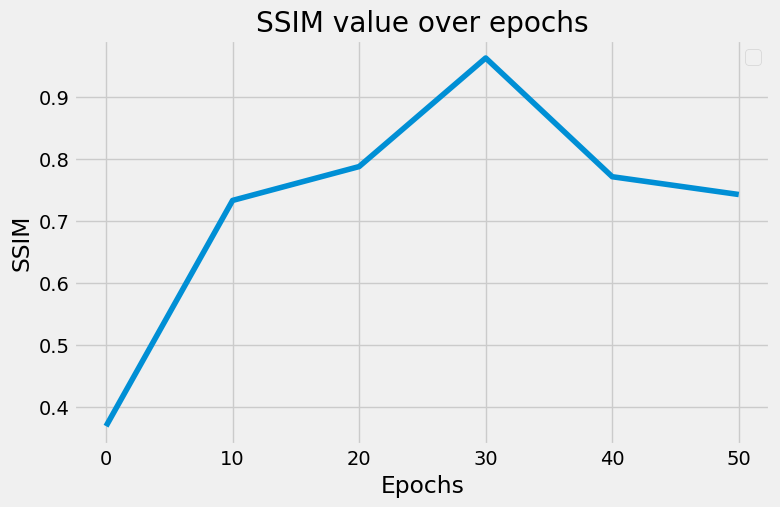

In [64]:
plot_metric_results(
    ssim_values, 
    epoch_values[::10], 
    "SSIM", 
    "SSIM value over epochs"
)

ssmi values over epochs


/tmp/ipykernel_1965806/3809575644.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


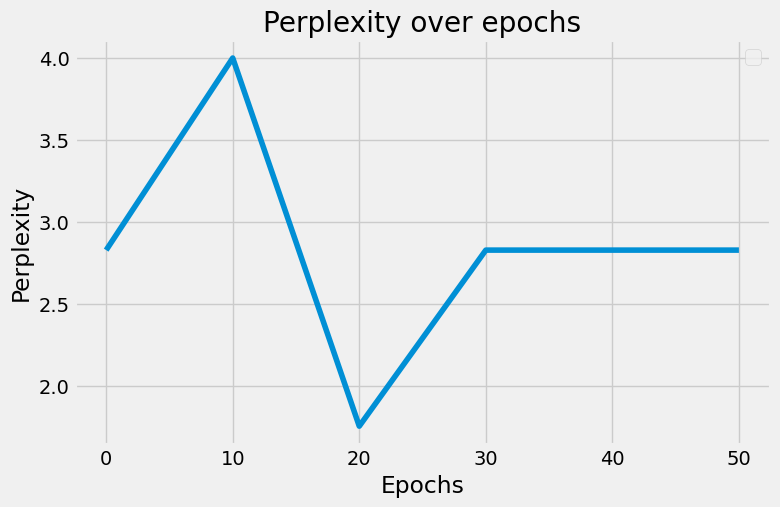

In [65]:
plot_metric_results(
    perplexity_values, 
    epoch_values[::10], 
    "Perplexity", 
    "Perplexity over epochs"
)
# Result: 1 try uses 7 codebooks at 10 epochs
# Result: 2 try uses 8 codebooks at 10 epochs with decay = 0.75